Accuracy: 1.0

Predictions:

Digit Pattern:
[1 1 1]
[1 0 1]
[1 1 1]
[1 0 1]
[1 1 1]
Actual: Even
Predicted: Even


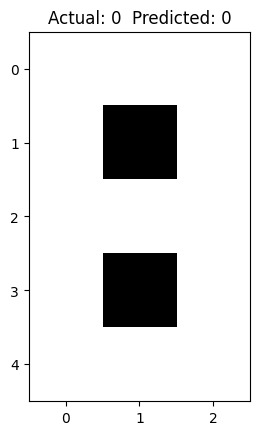


Digit Pattern:
[0 1 0]
[1 1 0]
[0 1 0]
[0 1 0]
[1 1 1]
Actual: Odd
Predicted: Odd


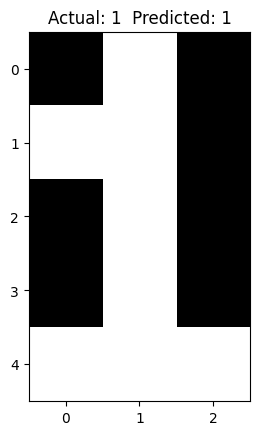


Digit Pattern:
[1 1 1]
[1 0 0]
[1 1 1]
[0 0 1]
[1 1 1]
Actual: Odd
Predicted: Odd


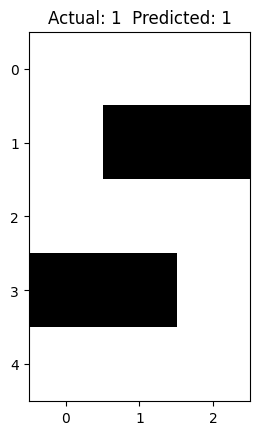

In [1]:
# Program: Perceptron Neural Network to Recognize Even and Odd Numbers
# Digits are given in ASCII form (0 to 9)

# Import libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ASCII representation of digits (5x3 matrix)
# 1 = white pixel, 0 = black pixel

digits_ascii = {
    0: ["111",
        "101",
        "101",
        "101",
        "111"],

    1: ["010",
        "110",
        "010",
        "010",
        "111"],

    2: ["111",
        "001",
        "111",
        "100",
        "111"],

    3: ["111",
        "001",
        "111",
        "001",
        "111"],

    4: ["101",
        "101",
        "111",
        "001",
        "001"],

    5: ["111",
        "100",
        "111",
        "001",
        "111"],

    6: ["111",
        "100",
        "111",
        "101",
        "111"],

    7: ["111",
        "001",
        "010",
        "100",
        "100"],

    8: ["111",
        "101",
        "111",
        "101",
        "111"],

    9: ["111",
        "101",
        "111",
        "001",
        "111"]
}

# Convert ASCII patterns into numerical feature vectors
X = []
y = []

for digit, pattern in digits_ascii.items():

    # Flatten 5x3 matrix into 1D vector
    vector = []

    for row in pattern:
        for pixel in row:
            vector.append(int(pixel))

    X.append(vector)

    # Even = 0, Odd = 1
    if digit % 2 == 0:
        y.append(0)
    else:
        y.append(1)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Perceptron model
model = Perceptron(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict output
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display predictions
print("\nPredictions:")
for i in range(len(X_test)):

    print("\nDigit Pattern:")

    # Reshape into 5x3 matrix for display
    img = X_test[i].reshape(5, 3)

    for row in img:
        print(row)

    print("Actual:", "Even" if y_test[i] == 0 else "Odd")
    print("Predicted:", "Even" if y_pred[i] == 0 else "Odd")

    # Show image
    plt.imshow(img, cmap='gray')
    plt.title(f"Actual: {y_test[i]}  Predicted: {y_pred[i]}")
    plt.show()